In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

PATH = "data/new_assigned_memes_final_merged.csv"
NO = "NO_TEMPLATE"

df = pd.read_csv(PATH, low_memory=False)
df["template_final"] = df["template_final"].fillna(NO).astype(str).str.strip()

# Exclude NO_TEMPLATE
df_valid = df[df["template_final"].ne(NO)].copy()

print("Total rows:", len(df))
print("Rows excluding NO_TEMPLATE:", len(df_valid))
print("Unique templates (excluding NO_TEMPLATE):", df_valid["template_final"].nunique())

Total rows: 171793
Rows excluding NO_TEMPLATE: 93596
Unique templates (excluding NO_TEMPLATE): 26931


/var/folders/q9/sf8tjzc130s4gxh60ngggj4w0000gn/T/ipykernel_39562/3780361147.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


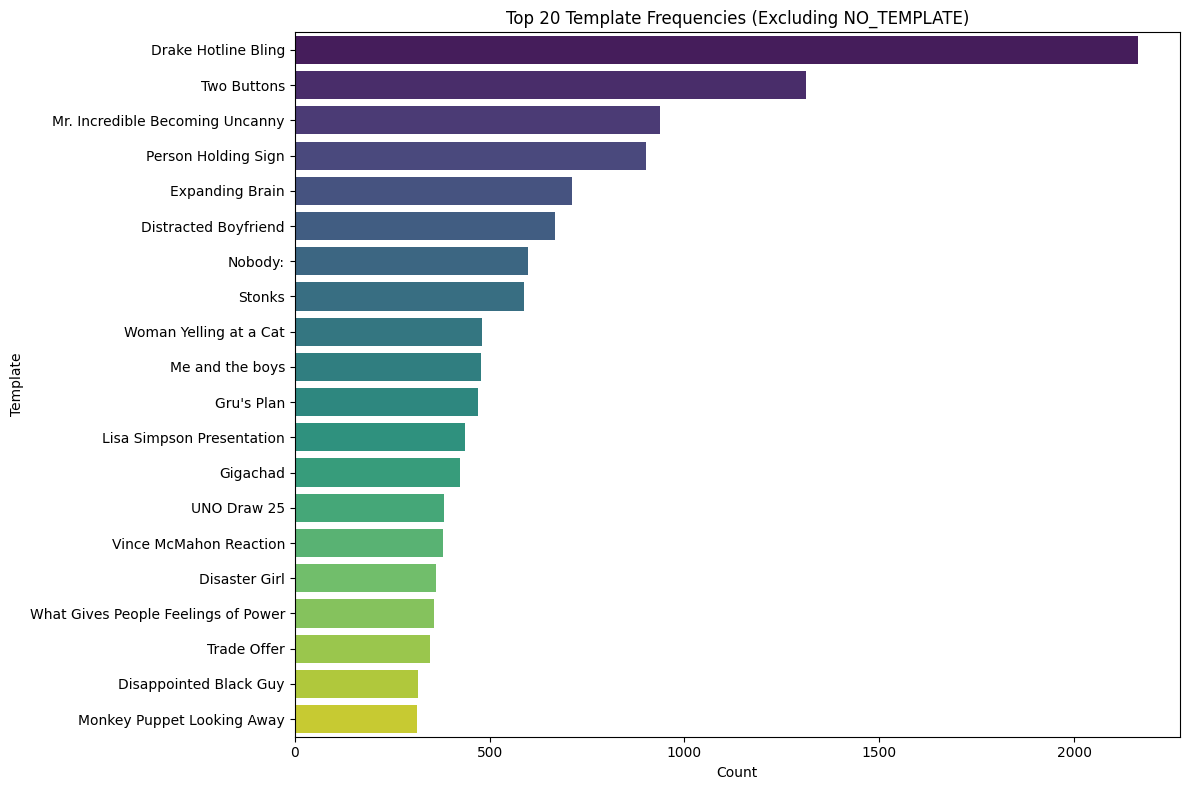

In [13]:
tpl_counts = df_valid["template_final"].value_counts()

plt.figure(figsize=(12, 8))
sns.barplot(
    x=tpl_counts.head(20).values,
    y=tpl_counts.head(20).index,
    palette="viridis"
)
plt.title("Top 20 Template Frequencies (Excluding NO_TEMPLATE)")
plt.xlabel("Count")
plt.ylabel("Template")
plt.tight_layout()
plt.show()


In [15]:
meme_sub = pd.read_parquet("data/meme_submissions.zst.parquet")
meme_sub.columns

Index(['id', 'score', 'title', 'body', 'url', 'image_url', 'post_link',
       'created_utc'],
      dtype='object')

## Clustering Code

In [17]:
from sentence_transformers import SentenceTransformer
from sklearn.cluster import AgglomerativeClustering

IN_PATH = "data/new_assigned_memes_final_merged.csv"
OUT_PATH = "data/new_assigned_memes_template_clustered.csv"
MAP_PATH = "data/template_cluster_mapping.csv"

NO = "NO_TEMPLATE"
TEMPLATE_COL = "template_final"
DIST_THRESHOLD = 0.20   # tune: lower=stricter, higher=more merges

In [ ]:

df = pd.read_csv(IN_PATH, low_memory=False)
df[TEMPLATE_COL] = df[TEMPLATE_COL].fillna(NO).astype(str).str.strip()

# Exclude NO_TEMPLATE for clustering
df_non_no = df[df[TEMPLATE_COL].ne(NO)].copy()

print("Rows total:", len(df))
print("Rows (non-NO_TEMPLATE):", len(df_non_no))
print("Unique templates (non-NO_TEMPLATE):", df_non_no[TEMPLATE_COL].nunique())


Rows total: 171793
Rows (non-NO_TEMPLATE): 93596
Unique templates (non-NO_TEMPLATE): 26931


In [19]:
counts = df_non_no[TEMPLATE_COL].value_counts()
n_classes = counts.shape[0]

print("Classes:", n_classes)
print("Median per class:", int(counts.median()))
print("Classes >= 20:", int((counts >= 20).sum()))
print("Classes >= 50:", int((counts >= 50).sum()))
print("Classes >= 100:", int((counts >= 100).sum()))
display(counts.head(20).rename("count").to_frame())


Classes: 26931
Median per class: 1
Classes >= 20: 558
Classes >= 50: 199
Classes >= 100: 73


,count
template_final,
Drake Hotline Bling,2163
Two Buttons,1312
Mr. Incredible Becoming Uncanny,938
Person Holding Sign,901
Expanding Brain,711
Distracted Boyfriend,668
Nobody:,599
Stonks,589
Woman Yelling at a Cat,481


In [21]:
import re
SYN_MAP = {
    r"\bman\b": "person",
    r"\bguy\b": "person",
    r"\bwoman\b": "person",
    r"\bkid\b": "child",
    r"\bkids\b": "children",
    r"\bchange my mind\b": "person holding sign",
}

def normalize_template_name(s: str) -> str:
    s = str(s).strip().lower()
    s = s.replace("&", " and ")
    s = re.sub(r"[^a-z0-9\s]", " ", s)
    s = re.sub(r"\s+", " ", s).strip()
    for pat, repl in SYN_MAP.items():
        s = re.sub(pat, repl, s)
    s = re.sub(r"\s+", " ", s).strip()
    return s

tpl_df = (
    df_non_no[TEMPLATE_COL]
    .value_counts()
    .rename_axis("template")
    .reset_index(name="count")
)
tpl_df["template_norm"] = tpl_df["template"].map(normalize_template_name)

display(tpl_df.head(20))

,template,count,template_norm
0,Drake Hotline Bling,2163,drake hotline bling
1,Two Buttons,1312,two buttons
2,Mr. Incredible Becoming Uncanny,938,mr incredible becoming uncanny
3,Person Holding Sign,901,person holding sign
4,Expanding Brain,711,expanding brain
5,Distracted Boyfriend,668,distracted boyfriend
6,Nobody:,599,nobody
7,Stonks,589,stonks
8,Woman Yelling at a Cat,481,person yelling at a cat
9,Me and the boys,477,me and the boys


In [22]:
norm_groups = (
    tpl_df.groupby("template_norm", as_index=False)
    .agg(
        variants=("template", list),
        total_count=("count", "sum")
    )
)

print("Unique normalized groups:", len(norm_groups))
display(norm_groups.head(20))

Unique normalized groups: 23982


,template_norm,variants,total_count
0,,"[Ñ, 🗿, ¯\_(ツ)_/¯]",21
1,0 days without nonsense,[0 Days Without Nonsense],1
2,0 drug 1 drug,[0 drug 1 drug],4
3,03 06 not great not terrible,"[03:06 not great, not terrible]",4
4,1 5 million peoples,[1.5 million peoples:],1
5,1 in 10 dentists,[1 in 10 dentists],1
6,1 in 4,[1 in 4],1
7,1 million people,[1 million people:],2
8,1 of people,[1% of people],1
9,1 of x 99 of y,"[1% of X, 99% of Y]",1


In [23]:
model = SentenceTransformer("all-MiniLM-L6-v2")
emb = model.encode(
    norm_groups["template_norm"].tolist(),
    normalize_embeddings=True,
    show_progress_bar=True
)

print("Embedding shape:", emb.shape)

python(37642) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.
Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1518.30it/s, Materializing param=pooler.dense.weight]                             
BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
Batches: 100%|██████████| 750/750 [00:13<00:00, 55.89it/s]

Embedding shape: (23982, 384)


In [24]:
clusterer = AgglomerativeClustering(
    n_clusters=None,
    metric="cosine",
    linkage="average",
    distance_threshold=DIST_THRESHOLD
)
norm_groups["cluster_id"] = clusterer.fit_predict(emb)

print("Clusters:", norm_groups["cluster_id"].nunique())
display(norm_groups.sort_values(["cluster_id", "total_count"], ascending=[True, False]).head(30))

Clusters: 17981


,template_norm,variants,total_count,cluster_id
17218,spongebob burn notice,[SpongeBob Burn Notice],4,0
17223,spongebob burning office,[SpongeBob Burning Office],2,0
17415,spongebob in a fiery kitchen,[SpongeBob in a fiery kitchen],2,0
17421,spongebob in burning room,"[Spongebob in Burning Room, SpongeBob in Burni...",2,0
17217,spongebob burn it,[SpongeBob Burn It],1,0
17222,spongebob burning,[SpongeBob Burning],1,0
17418,spongebob in burning building,[SpongeBob in burning building],1,0
17419,spongebob in burning kitchen,[Spongebob in burning kitchen],1,0
17839,spongebob yeet it to flames,"[SpongeBob ""Yeet it to flames""]",1,0
12090,mordecai and rigby giving gifts,[Mordecai and Rigby giving gifts],1,1


In [25]:
count_lookup = dict(zip(tpl_df["template"], tpl_df["count"]))

rows = []
for r in norm_groups.itertuples(index=False):
    for v in r.variants:
        rows.append({
            "cluster_id": r.cluster_id,
            "template": v,
            "count": count_lookup.get(v, 0)
        })
variant_df = pd.DataFrame(rows)

canonical = (
    variant_df.sort_values(["cluster_id", "count"], ascending=[True, False])
    .groupby("cluster_id", as_index=False)
    .first()
    .rename(columns={"template": "canonical_template"})
)

cluster_map = norm_groups.merge(canonical[["cluster_id", "canonical_template"]], on="cluster_id", how="left")
display(cluster_map.head(20))

,template_norm,variants,total_count,cluster_id,canonical_template
0,,"[Ñ, 🗿, ¯\_(ツ)_/¯]",21,16257,Ñ
1,0 days without nonsense,[0 Days Without Nonsense],1,10393,0 Days Without Nonsense
2,0 drug 1 drug,[0 drug 1 drug],4,15739,0 drug 1 drug
3,03 06 not great not terrible,"[03:06 not great, not terrible]",4,9143,"03:06 not great, not terrible"
4,1 5 million peoples,[1.5 million peoples:],1,3261,1 million people:
5,1 in 10 dentists,[1 in 10 dentists],1,1263,9/10 Dentists
6,1 in 4,[1 in 4],1,12540,1 in 4
7,1 million people,[1 million people:],2,3261,1 million people:
8,1 of people,[1% of people],1,12968,1% of people
9,1 of x 99 of y,"[1% of X, 99% of Y]",1,12205,"1% of X, 99% of Y"


In [26]:
template_to_canonical = {}
for r in cluster_map.itertuples(index=False):
    for v in r.variants:
        template_to_canonical[v] = r.canonical_template

mapping_df = pd.DataFrame({
    "template_original": list(template_to_canonical.keys()),
    "template_clustered": list(template_to_canonical.values())
}).sort_values(["template_clustered", "template_original"])

display(mapping_df.head(50))

,template_original,template_clustered
6638,"""hits blunt""","""hits blunt"""
24,#10YEARSCHALLENGE,#10YEARSCHALLENGE
4607,#explainafilmotbadly,#explainafilmotbadly
4835,#firstworldproblems,#firstworldproblems
3,0 Days Without Nonsense,0 Days Without Nonsense
4,0 drug 1 drug,0 drug 1 drug
5,"03:06 not great, not terrible","03:06 not great, not terrible"
8,1 in 4,1 in 4
9,1 million people:,1 million people:
6,1.5 million peoples:,1 million people:


In [28]:
import numpy as np
df["template_clustered"] = np.where(
    df[TEMPLATE_COL].eq(NO),
    NO,
    df[TEMPLATE_COL].map(template_to_canonical).fillna(df[TEMPLATE_COL])
)

print("Unique before:", df[TEMPLATE_COL].nunique())
print("Unique after:", df["template_clustered"].nunique())

display(
    df[[TEMPLATE_COL, "template_clustered"]]
    .drop_duplicates()
    .sort_values(["template_clustered", TEMPLATE_COL])
    .head(60)
)

Unique before: 26932
Unique after: 17982


,template_final,template_clustered
75969,"""hits blunt""","""hits blunt"""
41282,#10YEARSCHALLENGE,#10YEARSCHALLENGE
49349,#explainafilmotbadly,#explainafilmotbadly
90836,#firstworldproblems,#firstworldproblems
452,0 Days Without Nonsense,0 Days Without Nonsense
88457,0 drug 1 drug,0 drug 1 drug
12382,"03:06 not great, not terrible","03:06 not great, not terrible"
94659,1 in 4,1 in 4
62839,1 million people:,1 million people:
69753,1.5 million peoples:,1 million people:


In [30]:
# Cell 11: Save outputs
df.to_csv(OUT_PATH, index=False)
mapping_df.to_csv(MAP_PATH, index=False)

print("Saved:", OUT_PATH)
print("Saved:", MAP_PATH)


Saved: data/new_assigned_memes_template_clustered.csv
Saved: data/template_cluster_mapping.csv


In [29]:
audit = (
    mapping_df.groupby("template_clustered", as_index=False)
    .agg(n_original_labels=("template_original", "nunique"))
    .sort_values("n_original_labels", ascending=False)
)

display(audit.head(20))

,template_clustered,n_original_labels
9269,Mom: We have X at home,75
6276,"It is Wednesday, my dudes",50
12905,"SpongeBob ""I Need It"" Meme",45
14793,"Therapist: [X] isn't real, he can't hurt you. ...",36
7059,Kermit the Frog,34
13157,SpongeBob and Patrick,29
14485,The Undertaker and AJ Styles,27
17643,You vs the guy she tells you not to worry about,25
5306,I bet he's thinking about other women,24
3731,"Gentlemen, it is with great pleasure to inform...",22
